# Retail Sales Data - Exploratory Data Analysis

**OIBSIP Data Analytics - Task 1**

This notebook explores sales performance, customer demographics, product demand, category revenue, numerical relationships, and purchasing patterns. The analysis is reproducible with the included `retail_sales.csv` file.

## 1. Introduction

The goal is to convert retail transaction data into business insights that support sales planning, marketing, inventory decisions, and customer targeting. Each major visualization is followed by an observation generated from the data.

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Load Dataset

In [68]:
DATA_PATH = "retail_sales.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Customer ID,Gender,Age,Product Category,Product,Quantity,Price per Unit,Total Amount
0,2024-01-03,C1001,Female,28,Electronics,Wireless Headphones,2,45,90
1,2024-01-05,C1002,Male,35,Clothing,Denim Jacket,1,60,60
2,2024-01-09,C1003,Female,22,Beauty,Skincare Set,3,25,75
3,2024-01-12,C1004,Male,41,Electronics,Smartphone,1,650,650
4,2024-01-18,C1005,Female,31,Home Decor,Table Lamp,2,35,70


## 3. Initial Inspection

In [69]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.dtypes.rename("data_type").to_frame())
display(df.isna().sum().rename("missing_values").to_frame())
display(df.describe(include="all").T)

Rows: 61
Columns: 9


,data_type
Date,str
Customer ID,str
Gender,str
Age,int64
Product Category,str
Product,str
Quantity,int64
Price per Unit,int64
Total Amount,int64


,missing_values
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Product,0
Quantity,0
Price per Unit,0
Total Amount,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,61,61,2024-01-03,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,61,61,C1001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,61,2,Female,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,61.0,NaN,NaN,NaN,36.95082,10.392988,21.0,29.0,35.0,44.0,61.0
Product Category,61,4,Electronics,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,61,10,Smartphone,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,61.0,NaN,NaN,NaN,1.967213,0.948107,1.0,1.0,2.0,2.0,5.0
Price per Unit,61.0,NaN,NaN,NaN,207.786885,308.622645,20.0,30.0,55.0,80.0,900.0
Total Amount,61.0,NaN,NaN,NaN,274.754098,362.946766,20.0,60.0,90.0,180.0,1300.0


## 4. Data Cleaning

The date field is converted to datetime, duplicate rows are removed, and numeric fields are checked for invalid non-positive values. No records are removed solely because they are unusual.

In [70]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
numeric_columns = ["Age", "Quantity", "Price per Unit", "Total Amount"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
duplicate_count = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
invalid_values = (df[["Age", "Quantity", "Price per Unit", "Total Amount"]] <= 0).sum()
print(f"Duplicate rows removed: {duplicate_count}")
print("Invalid non-positive values by numeric column:")
display(invalid_values.rename("invalid_count").to_frame())
print(f"Remaining missing values: {int(df.isna().sum().sum())}")

Duplicate rows removed: 0
Invalid non-positive values by numeric column:


,invalid_count
Age,0
Quantity,0
Price per Unit,0
Total Amount,0


Remaining missing values: 0


## 5. Descriptive Statistics

In [71]:
stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
}).round(2)
stats

,Mean,Median,Mode,Standard Deviation
Age,36.95,35.0,26.0,10.39
Quantity,1.97,2.0,2.0,0.95
Price per Unit,207.79,55.0,650.0,308.62
Total Amount,274.75,90.0,60.0,362.95


## 6. Monthly Sales Trend

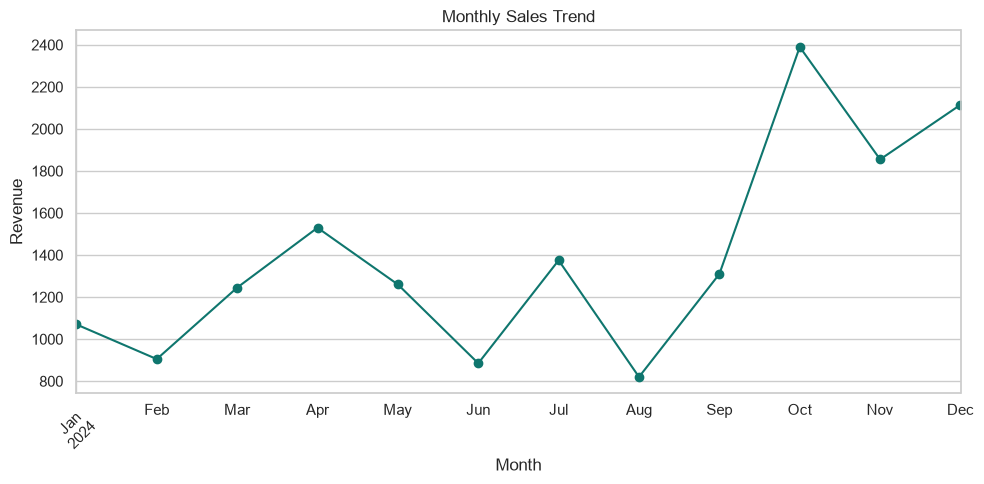

In [72]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales.plot(marker="o", color="#0f766e")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation
The line chart shows how revenue changes month by month. The calculated statement below identifies the strongest and weakest months in this dataset.

In [73]:
best_month = monthly_sales.idxmax()
weakest_month = monthly_sales.idxmin()
display(Markdown(f"Revenue was highest in **{best_month}** (${monthly_sales.max():,.0f}) and lowest in **{weakest_month}** (${monthly_sales.min():,.0f})."))

Revenue was highest in **2024-10** ($2,390) and lowest in **2024-08** ($820).

## 7. Quarterly Sales Trend

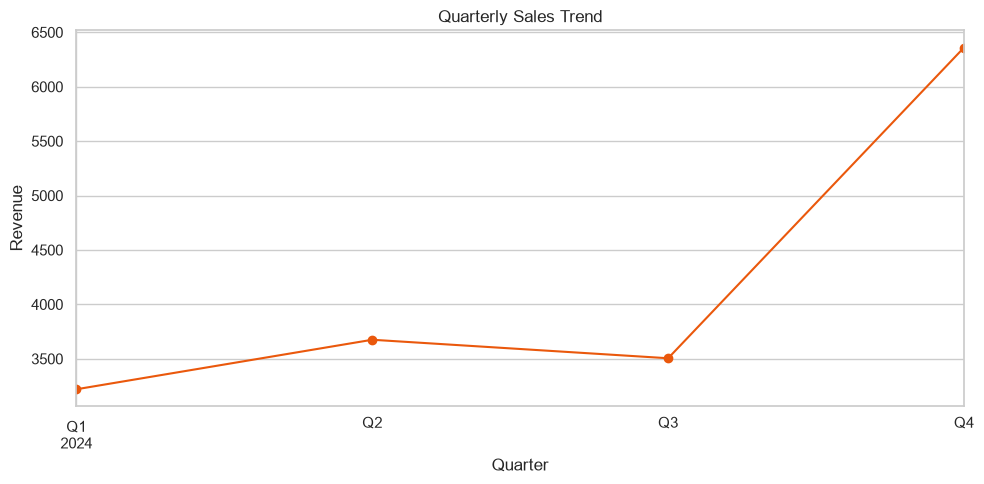

In [74]:
df["Quarter"] = df["Date"].dt.to_period("Q")
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()
quarterly_sales.plot(marker="o", color="#ea580c")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Observation
Quarterly aggregation reduces daily noise and makes broader seasonal differences easier to compare.

In [75]:
best_quarter = quarterly_sales.idxmax()
display(Markdown(f"**{best_quarter}** generated the highest quarterly revenue at **${quarterly_sales.max():,.0f}**."))

**2024Q4** generated the highest quarterly revenue at **$6,360**.

## 8. Customer Age Analysis

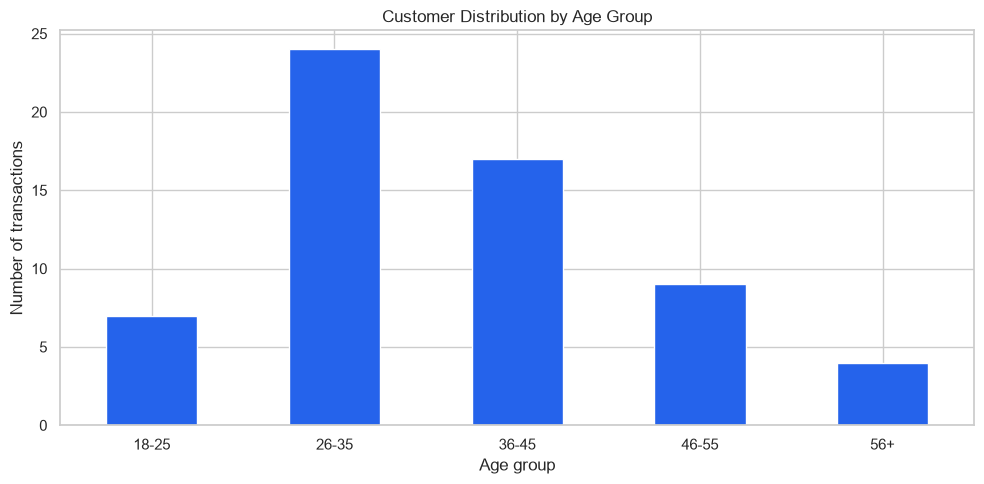

In [76]:
age_bins = [17, 25, 35, 45, 55, np.inf]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df["Age Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)
age_counts = df["Age Group"].value_counts().reindex(age_labels, fill_value=0)
age_counts.plot(kind="bar", color="#2563eb")
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age group")
plt.ylabel("Number of transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

In [77]:
largest_age_group = age_counts.idxmax()
display(Markdown(f"The largest represented customer age group is **{largest_age_group}**, with **{age_counts.max()}** transactions."))

The largest represented customer age group is **26-35**, with **24** transactions.

## 9. Gender Analysis

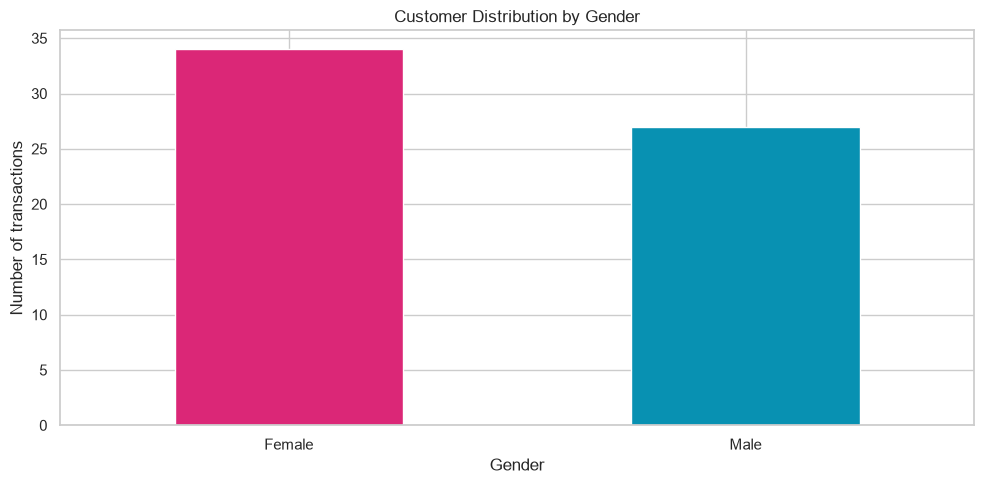

In [78]:
gender_counts = df["Gender"].value_counts()
gender_counts.plot(kind="bar", color=["#db2777", "#0891b2"] )
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

In [79]:
leading_gender = gender_counts.idxmax()
share = gender_counts.max() / gender_counts.sum() * 100
display(Markdown(f"**{leading_gender}** represents the largest share of transactions at **{share:.1f}%**."))

**Female** represents the largest share of transactions at **55.7%**.

## 10. Top 10 Best-Selling Products

Best-selling is defined here as the products with the highest total quantity sold.

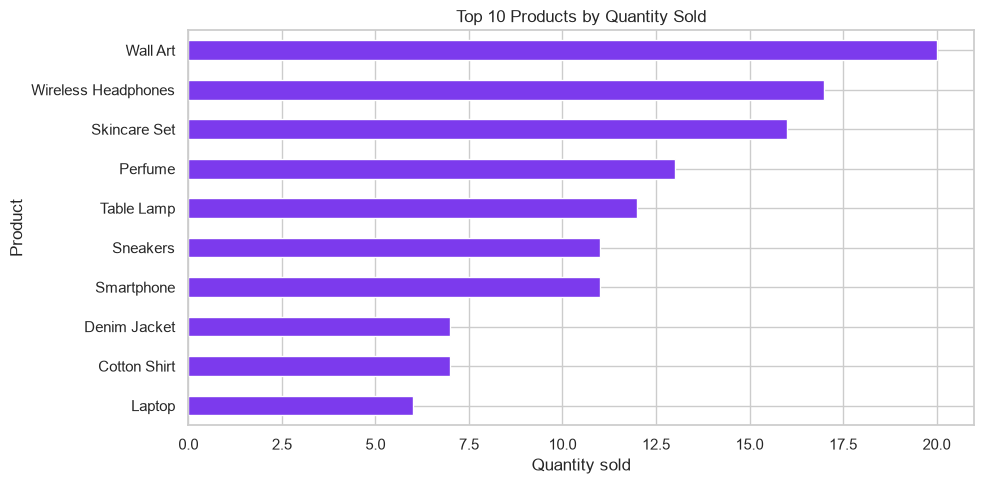

In [80]:
top_products = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products.sort_values().plot(kind="barh", color="#7c3aed")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### Observation

In [1]:
display(Markdown(f"**{top_products.index[0]}** is the leading product by quantity, with **{top_products.iloc[0]}** units sold."))

NameError: name 'Markdown' is not defined

## 11. Revenue by Product Category

In [2]:
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
category_revenue.plot(kind="bar", color="#16a34a")
plt.title("Revenue by Product Category")
plt.xlabel("Product category")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

### Observation

In [3]:
display(Markdown(f"**{category_revenue.index[0]}** contributes the most revenue, totaling **${category_revenue.iloc[0]:,.0f}**."))

NameError: name 'Markdown' is not defined

## 12. Correlation Analysis

In [4]:
correlation = df[numeric_columns].corr()
sns.heatmap(correlation, annot=True, cmap="RdYlBu_r", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

### Observation
Correlation measures linear association, not causation. The heatmap helps identify which numeric fields move together and deserve further investigation.

In [5]:
corr_pairs = correlation.where(~np.eye(correlation.shape[0], dtype=bool)).stack().abs().sort_values(ascending=False)
strongest_pair = corr_pairs.index[0]
display(Markdown(f"The strongest absolute numeric correlation is between **{strongest_pair[0]}** and **{strongest_pair[1]}** ({correlation.loc[strongest_pair[0], strongest_pair[1]]:.2f})."))

NameError: name 'correlation' is not defined

## 13. Additional Visualization: Sales by Day of Week

In [6]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Day of Week"] = df["Date"].dt.day_name()
daily_sales = df.groupby("Day of Week")["Total Amount"].sum().reindex(day_order, fill_value=0)
daily_sales.plot(kind="bar", color="#ca8a04")
plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

### Observation

In [7]:
best_day = daily_sales.idxmax()
display(Markdown(f"**{best_day}** has the highest total revenue at **${daily_sales.max():,.0f}**, which can guide timing for promotions and staffing."))

NameError: name 'daily_sales' is not defined

## 14. Key Findings

In [8]:
findings = [
    f"Best month: {best_month} with ${monthly_sales.max():,.0f} revenue.",
    f"Best quarter: {best_quarter} with ${quarterly_sales.max():,.0f} revenue.",
    f"Largest age group: {largest_age_group}.",
    f"Top product by quantity: {top_products.index[0]}.",
    f"Top revenue category: {category_revenue.index[0]}.",
    f"Highest-revenue day: {best_day}."
]
display(pd.DataFrame({"Finding": findings}))

NameError: name 'best_month' is not defined

## 15. Business Recommendations

1. **Inventory planning:** Maintain stronger stock coverage for the top products and the leading revenue category before the highest-performing month and quarter.
2. **Targeted marketing:** Build campaigns around the largest age group and test product bundles aligned with its highest-demand products.
3. **Promotion timing:** Schedule promotional activity and staffing around the strongest day of the week and the strongest sales periods.
4. **Category strategy:** Use the category revenue comparison to protect availability in high-value categories while testing ways to increase lower-performing category demand.

## 16. Conclusion

This EDA provides a compact view of retail performance across time, customers, products, and categories. The combination of descriptive statistics, trend analysis, segmentation, and correlation analysis creates a foundation for more advanced forecasting, customer segmentation, and profitability analysis when additional fields such as discount and profit become available.